In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv('telecom_customers.csv')

In [4]:
df.sample(5)

,CustomerID,Name,PlanType,RechargeAmount,DataUsageGB,CallMinutes,City
76,4077,User_77,Postpaid,1541,29.30,1885,Chennai
22,4023,User_23,Prepaid,4447,1.30,134,Mumbai
16,4017,User_17,Prepaid,1198,25.90,1925,Delhi
73,4074,User_74,Prepaid,773,63.10,3162,Hyderabad
85,4086,User_86,Postpaid,2395,74.56,3825,Hyderabad


In [5]:
df.shape

(100, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      100 non-null    int64  
 1   Name            100 non-null    str    
 2   PlanType        100 non-null    str    
 3   RechargeAmount  100 non-null    int64  
 4   DataUsageGB     100 non-null    float64
 5   CallMinutes     100 non-null    int64  
 6   City            100 non-null    str    
dtypes: float64(1), int64(3), str(3)
memory usage: 5.6 KB


# NUMPY

In [7]:
df.sample(3)

,CustomerID,Name,PlanType,RechargeAmount,DataUsageGB,CallMinutes,City
50,4051,User_51,Postpaid,1514,72.11,3373,Mumbai
39,4040,User_40,Prepaid,1680,64.02,505,Mumbai
70,4071,User_71,Prepaid,3423,19.28,490,Mumbai


In [8]:
np.sum(df['RechargeAmount'])

np.int64(246434)

In [9]:
np.average(df['DataUsageGB'])

np.float64(49.1935)

In [10]:
np.max(df['CallMinutes'])

np.int64(4934)

# PANDAS


In [11]:
df.sample(3)

,CustomerID,Name,PlanType,RechargeAmount,DataUsageGB,CallMinutes,City
46,4047,User_47,Prepaid,2035,73.67,2758,Hyderabad
97,4098,User_98,Postpaid,4418,96.25,4743,Chennai
80,4081,User_81,Postpaid,253,28.20,223,Hyderabad


In [12]:
df.groupby('PlanType')['CustomerID'].count()

PlanType
Postpaid    54
Prepaid     46
Name: CustomerID, dtype: int64

In [13]:
df.loc[df['RechargeAmount'] > 3000, ['Name', 'PlanType','RechargeAmount']].head()

,Name,PlanType,RechargeAmount
0,User_1,Postpaid,3697
1,User_2,Prepaid,3223
4,User_5,Postpaid,4541
8,User_9,Postpaid,3083
10,User_11,Prepaid,3948


In [16]:
df.groupby('City')['RechargeAmount'].mean()

City
Chennai      2284.333333
Delhi        2734.421053
Hyderabad    2366.880000
Mumbai       2515.125000
Name: RechargeAmount, dtype: float64

In [17]:
df.groupby('City')['RechargeAmount'].mean().sort_values(ascending=False)


City
Delhi        2734.421053
Mumbai       2515.125000
Hyderabad    2366.880000
Chennai      2284.333333
Name: RechargeAmount, dtype: float64

In [18]:
df.nlargest(5,'DataUsageGB')

,CustomerID,Name,PlanType,RechargeAmount,DataUsageGB,CallMinutes,City
29,4030,User_30,Postpaid,3658,97.64,3854,Hyderabad
97,4098,User_98,Postpaid,4418,96.25,4743,Chennai
66,4067,User_67,Postpaid,1665,96.19,3925,Hyderabad
26,4027,User_27,Postpaid,2919,95.43,4469,Mumbai
64,4065,User_65,Prepaid,4010,93.84,580,Mumbai


In [19]:
df.groupby('PlanType')['CallMinutes'].mean()

PlanType
Postpaid    2793.462963
Prepaid     2203.130435
Name: CallMinutes, dtype: float64

# MATPLOTLIB

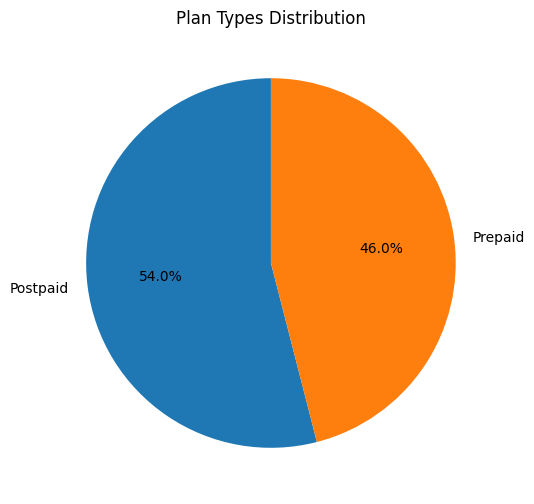

In [20]:
plan_counts = df['PlanType'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(plan_counts, labels=plan_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Plan Types Distribution")
plt.show()

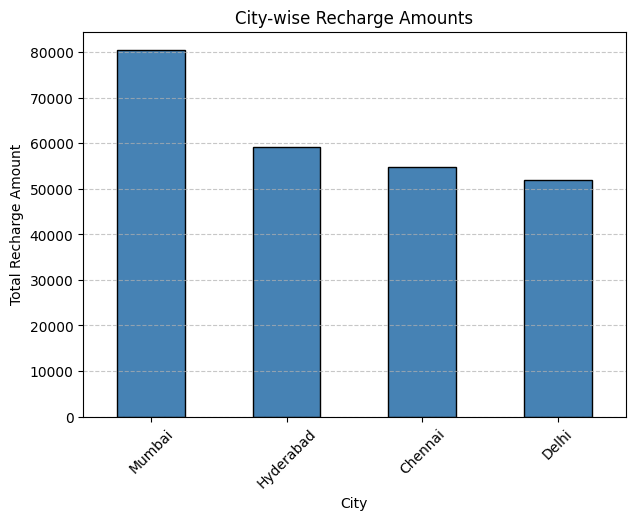

In [22]:
city_recharge = df.groupby('City')['RechargeAmount'].sum().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(7,5))
city_recharge.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("City-wise Recharge Amounts")
plt.xlabel("City")
plt.ylabel("Total Recharge Amount")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

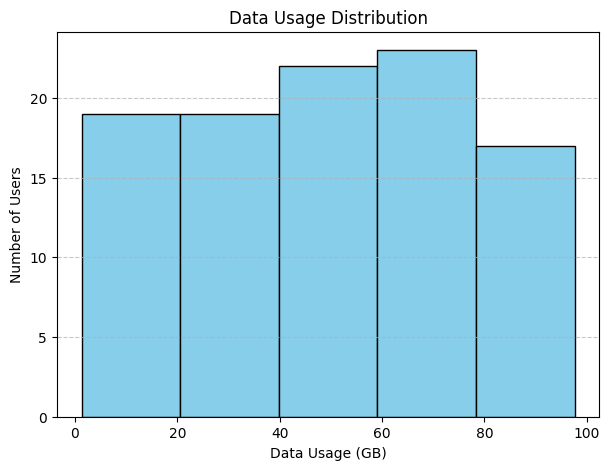

In [23]:
plt.figure(figsize=(7,5))
plt.hist(df['DataUsageGB'], bins=5, color='skyblue', edgecolor='black')
plt.title("Data Usage Distribution")
plt.xlabel("Data Usage (GB)")
plt.ylabel("Number of Users")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()